# Systematic Evaluation and Enhancement of bio.tools Annotation Quality

## Overview

The quality of metadata in the ELIXIR bio.tools registry affects its usability for both end users and developers. However, the completeness and consistency of tool annotations vary significantly. This notebook investigates the current state of metadata quality and proposes a systematic framework to assess and improve it.

### Key Objectives
1. **Implement a scoring pipeline** to classify tools into annotation quality tiers (1-5)
2. **Analyze completeness patterns** across tool collections and domains
3. **Identify frequently missing attributes** and structural issues
4. **Integrate bio.tools linter output** into quality assessment
5. **Propose revisions** to the Tool Information Standards

### Expected Outcomes
- A comprehensive scoring and analysis pipeline for bio.tools metadata evaluation
- Visual and tabular reports highlighting completeness metrics per tier and domain
- An integrated dataset combining scoring, linter results, and tool metadata
- Evidence-based recommendations for improving Tool Information Standards

---

## 1. Import Required Libraries and Define Constants

First, we'll import all necessary Python libraries for data handling, API requests, JSON schema validation, and visualization.

In [46]:
# Import required libraries and set up environment
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
import yaml
import warnings
from typing import Dict, List, Any, Optional
from collections import Counter

# Set up project paths
current_dir = Path.cwd()
project_root = current_dir.parent
src_dir = project_root / 'src'

# Add src directory to Python path
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print(f"✓ Added {src_dir} to Python path")

# Now import the actual project modules
try:
    from data_collection.api_client import BioToolsAPIClient
    from data_collection.data_parser import BioToolsDataParser
    from scoring.completeness_scorer import CompletenessScorer
    from scoring.tier_classifier import TierClassifier
    from analysis.statistics import QualityStatistics
    from visualization.charts import QualityVisualizer
    print("✓ Successfully imported all project modules")
    USE_REAL_MODULES = True
except ImportError as e:
    print(f"⚠ Warning: Could not import project modules: {e}")
    print("Will use simplified implementations for demonstration")
    USE_REAL_MODULES = False

# Configuration constants
API_BASE_URL = "https://bio.tools/api/tool/?format=json"
SCHEMA_URL = "https://raw.githubusercontent.com/bio-tools/biotoolsschema/main/jsonschema/biotoolsj.json"
CONFIG_PATH = str(project_root / 'config' / 'scoring_config.yaml')

# Data directories
DATA_DIR = project_root / 'data'
RESULTS_DIR = DATA_DIR / 'processed'
VIZ_DIR = DATA_DIR / 'visualizations'

# Create directories if they don't exist
for dir_path in [DATA_DIR, RESULTS_DIR, VIZ_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

print("✓ Libraries imported and constants defined")
print(f"✓ Data directories created: {DATA_DIR}, {RESULTS_DIR}, {VIZ_DIR}")

✓ Added c:\Users\gogai\Desktop\bio.tools-annotation-quality-evaluation\src to Python path
✓ Successfully imported all project modules
✓ Libraries imported and constants defined
✓ Data directories created: c:\Users\gogai\Desktop\bio.tools-annotation-quality-evaluation\data, c:\Users\gogai\Desktop\bio.tools-annotation-quality-evaluation\data\processed, c:\Users\gogai\Desktop\bio.tools-annotation-quality-evaluation\data\visualizations


## 2. Retrieve Tool Metadata from bio.tools API

We'll fetch tool entries from the bio.tools API. For this demonstration, we'll focus on proteomics tools as they represent a well-established domain with varying annotation quality.

In [47]:
# Data Collection and API Testing
print("🔄 Setting up data collection...")

if USE_REAL_MODULES:
    # Use the actual project API client
    print("✓ Using production API client")
    api_client = BioToolsAPIClient()
    
    # Fetch proteomics tools
    print("Fetching proteomics tools from bio.tools API...")
    
    topic="Proteins"
    
    proteomics_tools = api_client.get_tools_by_topic(topic, limit=30515)
    
    if proteomics_tools:
        print(f"✓ Retrieved {len(proteomics_tools)} tools with topic '{topic}'")
        
        print("\nSample tools retrieved:")
        for i, tool in enumerate(proteomics_tools):
            print(f"{i+1}. {tool.get('name', 'N/A')} ({tool.get('biotoolsID', 'N/A')})")
            description = tool.get('description', 'N/A')
            if len(description) > 100:
                description = description[:100] + "..."
            print(f"   Description: {description}")
            print()
    else:
        print("❌ No tools retrieved")
        
else:
    # Simplified API client for demonstration
    import requests
    import time
    
    class SimpleAPIClient:
        def __init__(self):
            self.base_url = "https://bio.tools/api/tool/?format=json"
            
        def get_tools_by_topic(self, topic, limit=50):
            params = {
                'topic': topic,
                'page_size': min(limit, 50),
                'page': 1,
                'format': 'json'
            }
            
            try:
                headers = {'Accept': 'application/json'}
                response = requests.get(self.base_url, params=params, headers=headers, timeout=30)
                response.raise_for_status()
                data = response.json()
                return data.get('list', [])[:limit]
            except Exception as e:
                print(f"Error fetching data: {e}")
                return []
    
    print("⚠ Using simplified API client implementation")
    api_client = SimpleAPIClient()
    
    # Fetch proteomics tools
    print("Fetching proteomics tools from bio.tools API...")
    proteomics_tools = api_client.get_tools_by_topic('Proteomics', limit=50)
    
    if proteomics_tools:
        print(f"✓ Retrieved {len(proteomics_tools)} proteomics tools")
        
        print("\nSample tools retrieved:")
        for i, tool in enumerate(proteomics_tools[:5]):
            print(f"{i+1}. {tool.get('name', 'N/A')} ({tool.get('biotoolsID', 'N/A')})")
            description = tool.get('description', 'N/A')
            if len(description) > 100:
                description = description[:100] + "..."
            print(f"   Description: {description}")
            print()
    else:
        print("❌ No tools retrieved")

🔄 Setting up data collection...
✓ Using production API client
Fetching proteomics tools from bio.tools API...
✓ Retrieved 50 tools with topic 'Proteins'

Sample tools retrieved:
1. PAE Viewer (pae_viewer)
   Description: Webserver for the interactive visualization of the predicted aligned error for multimer structure pr...

2. qfeatures (qfeatures)
   Description: QFeatures is a Bioconductor package that provides infrastructure to management and process quantitat...

3. VADR (VADR)
   Description: Classification and annotation of viral sequences based on RefSeq annotation.

4. Pyteomics (pyteomics)
   Description: Framework for proteomics data analysis, supporting mzML, MGF, pepXML and more.

5. OmicsQ (OmicsQ)
   Description: OmicsQ is a Shiny-based web application designed for preprocessing and quantitative analysis of Omic...

6. PRISM (prism-ppi)
   Description: Fast and accurate prediction of protein-protein interactions (PPIs).

7. ProteinPrompt (proteinprompt)
   Description: A 

## 3. Validate Metadata Against biotoolsSchema

We'll use JSON schema validation to check each tool's metadata for compliance with the biotoolsSchema, identifying structural issues.

In [48]:
# Simple schema validation implementation

def validate_tool_schema(tool_data):
    """Simple validation check for essential fields."""
    validation_result = {
        'is_valid': True,
        'errors': [],
        'warnings': []
    }
    
    # Check required fields
    required_fields = ['biotoolsID', 'name', 'description', 'homepage']
    for field in required_fields:
        if field not in tool_data or not tool_data[field]:
            validation_result['errors'].append(f"Missing required field: {field}")
            validation_result['is_valid'] = False
    
    # Check optional but important fields
    important_fields = ['function', 'topic', 'toolType', 'license']
    for field in important_fields:
        if field not in tool_data or not tool_data[field]:
            validation_result['warnings'].append(f"Missing important field: {field}")
    
    return validation_result

# Validate all tools
print("Validating tool metadata against schema requirements...")
validation_results = []

for tool in proteomics_tools:
    biotools_id = tool.get('biotoolsID', 'unknown')
    validation = validate_tool_schema(tool)
    validation['biotoolsID'] = biotools_id
    validation_results.append(validation)

# Summary of validation results
valid_tools = sum(1 for r in validation_results if r['is_valid'])
invalid_tools = len(validation_results) - valid_tools

print(f"✓ Validation complete:")
print(f"  - Valid tools: {valid_tools}")
print(f"  - Invalid tools: {invalid_tools}")
print(f"  - Validation rate: {valid_tools/len(validation_results)*100:.1f}%")

# Most common validation errors
all_errors = []
all_warnings = []
for result in validation_results:
    all_errors.extend(result['errors'])
    all_warnings.extend(result['warnings'])

print(f"\nMost common errors:")
error_counts = Counter(all_errors)
for error, count in error_counts.most_common(5):
    print(f"  - {error}: {count} tools")

print(f"\nMost common warnings:")
warning_counts = Counter(all_warnings)
for warning, count in warning_counts.most_common(5):
    print(f"  - {warning}: {count} tools")

Validating tool metadata against schema requirements...
✓ Validation complete:
  - Valid tools: 50
  - Invalid tools: 0
  - Validation rate: 100.0%

Most common errors:

Most common warnings:
  - Missing important field: license: 22 tools
  - Missing important field: toolType: 6 tools
  - Missing important field: function: 4 tools


## 4. Implement Tier-Based Scoring System

We'll implement a comprehensive scoring system that maps Tool Information Standards to a 5-tier classification system based on metadata richness and completeness.

In [49]:
# Quality Scoring and Tier Classification
print("📊 Setting up quality scoring system...")

if USE_REAL_MODULES:
    # Use the actual project scoring components
    print("✓ Using production scoring modules")
    
    # Load scoring configuration
    try:
        with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
            SCORING_CONFIG = yaml.safe_load(f)
        print(f"✓ Loaded scoring configuration from {CONFIG_PATH}")
    except Exception as e:
        print(f"⚠ Could not load config file: {e}")
        # Use default config
        SCORING_CONFIG = {
            'scoring': {
                'weights': {
                    'basic_info': 20,
                    'detailed_description': 15,
                    'technical_details': 25,
                    'documentation': 20,
                    'accessibility': 10,
                    'community': 10
                },
                'tiers': {
                    'tier_1': [0, 20],
                    'tier_2': [21, 40],
                    'tier_3': [41, 60],
                    'tier_4': [61, 80],
                    'tier_5': [81, 100]
                }
            }
        }
    
    # Initialize scoring components
    scorer = CompletenessScorer(CONFIG_PATH)
    classifier = TierClassifier()
    
    # Score all tools
    print("Scoring tools using tier-based system...")
    scoring_results = []
    
    for tool in proteomics_tools:
        try:
            score_result = scorer.score_tool(tool)
            tier_result = classifier.classify_tool(score_result)
            
            # Combine results - fixed key name
            combined_result = {
                **score_result,
                'tier': tier_result['tier'],
                'tier_name': tier_result['tier_name'],
                'tier_description': tier_result['tier_description']  # Fixed: was 'description'
            }
            scoring_results.append(combined_result)
            
        except Exception as e:
            print(f"⚠ Error scoring tool {tool.get('biotoolsID', 'unknown')}: {e}")
            continue
    
    print(f"✅ Successfully scored {len(scoring_results)} tools")
    
    # Display results summary
    if scoring_results:
        scores = [r['total_score'] for r in scoring_results]
        tiers = [r['tier'] for r in scoring_results]
        
        print(f"\n📈 Scoring Summary:")
        print(f"   Average Score: {np.mean(scores):.2f}/100")
        print(f"   Score Range: {np.min(scores):.2f} - {np.max(scores):.2f}")
        print(f"   Standard Deviation: {np.std(scores):.2f}")
        
        tier_counts = {}
        for tier in tiers:
            tier_counts[tier] = tier_counts.get(tier, 0) + 1
        
        print(f"\n🏆 Tier Distribution:")
        tier_names = {1: 'Minimal', 2: 'Basic', 3: 'Moderate', 4: 'Good', 5: 'Excellent'}
        for tier in sorted(tier_counts.keys()):
            count = tier_counts[tier]
            percentage = (count / len(scoring_results)) * 100
            print(f"   Tier {tier} ({tier_names.get(tier, 'Unknown')}): {count} tools ({percentage:.1f}%)")

else:
    # Simplified scoring implementation
    print("⚠ Using simplified scoring implementation")
    
    def calculate_total_score(tool):
        """Simplified scoring function for demonstration."""
        score = 0
        total_possible = 100
        
        # Basic info scoring (30 points)
        if tool.get('name'): score += 5
        if tool.get('description'): score += 10
        if tool.get('homepage'): score += 5
        if tool.get('biotoolsID'): score += 5
        if tool.get('version'): score += 5
        
        # Function and topic (20 points)
        if tool.get('function'): score += 10
        if tool.get('topic'): score += 10
        
        # Technical details (25 points)
        if tool.get('toolType'): score += 5
        if tool.get('language'): score += 5
        if tool.get('operatingSystem'): score += 5
        if tool.get('license'): score += 5
        if tool.get('cost'): score += 5
        
        # Documentation (15 points)
        if tool.get('documentation'): score += 8
        if tool.get('publication'): score += 7
        
        # Accessibility (10 points)
        if tool.get('download'): score += 5
        if tool.get('link'): score += 5
        
        return min(score, total_possible)
    
    def determine_tier(score):
        """Determine tier based on score."""
        if score >= 81: return 5
        elif score >= 61: return 4
        elif score >= 41: return 3
        elif score >= 21: return 2
        else: return 1
    
    # Score tools using simplified method
    print("Scoring tools using simplified system...")
    scoring_results = []
    
    for tool in proteomics_tools:
        try:
            total_score = calculate_total_score(tool)
            tier = determine_tier(total_score)
            
            result = {
                'biotoolsID': tool.get('biotoolsID', 'unknown'),
                'name': tool.get('name', 'unknown'),
                'total_score': total_score,
                'tier': tier,
                'tier_name': {1: 'Minimal', 2: 'Basic', 3: 'Moderate', 4: 'Good', 5: 'Excellent'}[tier]
            }
            scoring_results.append(result)
            
        except Exception as e:
            print(f"⚠ Error scoring tool {tool.get('biotoolsID', 'unknown')}: {e}")
    
    print(f"✅ Successfully scored {len(scoring_results)} tools")
    
    # Display simplified results
    if scoring_results:
        scores = [r['total_score'] for r in scoring_results]
        tiers = [r['tier'] for r in scoring_results]
        
        print(f"\n📈 Scoring Summary:")
        print(f"   Average Score: {np.mean(scores):.2f}/100")
        print(f"   Score Range: {np.min(scores):.2f} - {np.max(scores):.2f}")
        
        tier_counts = {}
        for tier in tiers:
            tier_counts[tier] = tier_counts.get(tier, 0) + 1
        
        print(f"\n🏆 Tier Distribution:")
        tier_names = {1: 'Minimal', 2: 'Basic', 3: 'Moderate', 4: 'Good', 5: 'Excellent'}
        for tier in sorted(tier_counts.keys()):
            count = tier_counts[tier]
            percentage = (count / len(scoring_results)) * 100
            print(f"   Tier {tier} ({tier_names.get(tier, 'Unknown')}): {count} tools ({percentage:.1f}%)")

INFO:scoring.completeness_scorer:Loaded configuration from c:\Users\gogai\Desktop\bio.tools-annotation-quality-evaluation\config\scoring_config.yaml


📊 Setting up quality scoring system...
✓ Using production scoring modules
✓ Loaded scoring configuration from c:\Users\gogai\Desktop\bio.tools-annotation-quality-evaluation\config\scoring_config.yaml
Scoring tools using tier-based system...
✅ Successfully scored 50 tools

📈 Scoring Summary:
   Average Score: 55.93/100
   Score Range: 33.86 - 81.29
   Standard Deviation: 11.93

🏆 Tier Distribution:
   Tier 1 (Minimal): 2 tools (4.0%)
   Tier 2 (Basic): 2 tools (4.0%)
   Tier 3 (Moderate): 30 tools (60.0%)
   Tier 4 (Good): 14 tools (28.0%)
   Tier 5 (Excellent): 2 tools (4.0%)


## 5. Analyze Completeness Patterns Across Tool Collections

Let's aggregate and visualize completeness scores by different dimensions to identify trends and gaps in annotation quality.

In [50]:
# Statistical Analysis and Quality Assessment
print("📊 Performing statistical analysis...")

# Check if we have scoring results
if not scoring_results:
    print("❌ No scoring results available. Re-running scoring process...")
    
    # Re-run scoring process
    if USE_REAL_MODULES and 'proteomics_tools' in globals() and proteomics_tools:
        try:
            # Re-initialize scoring components
            scorer = CompletenessScorer(CONFIG_PATH)
            classifier = TierClassifier()
            
            print("🔄 Re-scoring all tools...")
            scoring_results = []
            
            for i, tool in enumerate(proteomics_tools):
                try:
                    score_result = scorer.score_tool(tool)
                    tier_result = classifier.classify_tool(score_result)
                    
                    # Combine results
                    combined_result = {
                        **score_result,
                        'tier': tier_result['tier'],
                        'tier_name': tier_result['tier_name'],
                        'tier_description': tier_result['description']
                    }
                    scoring_results.append(combined_result)
                    
                    if (i + 1) % 10 == 0:
                        print(f"   ✓ Scored {i + 1}/{len(proteomics_tools)} tools")
                        
                except Exception as e:
                    print(f"   ⚠ Error scoring tool {tool.get('biotoolsID', 'unknown')}: {e}")
                    continue
            
            print(f"✅ Successfully scored {len(scoring_results)} tools")
            
        except Exception as e:
            print(f"❌ Error in scoring process: {e}")
            scoring_results = []

# Now perform analysis if we have results
if USE_REAL_MODULES and scoring_results:
    # Use real statistics module
    stats_analyzer = QualityStatistics()
    
    # Generate comprehensive statistics
    basic_stats = stats_analyzer.generate_basic_statistics(scoring_results)
    
    print("✅ Generated comprehensive statistics")
    print(f"\n📈 Score Statistics:")
    score_stats = basic_stats.get('score_statistics', {})
    print(f"   Mean: {score_stats.get('mean', 0):.2f}")
    print(f"   Median: {score_stats.get('median', 0):.2f}")
    print(f"   Standard Deviation: {score_stats.get('std', 0):.2f}")
    print(f"   Range: {score_stats.get('min', 0):.2f} - {score_stats.get('max', 0):.2f}")
    
    print(f"\n🏆 Tier Distribution:")
    tier_dist = basic_stats.get('tier_distribution', {})
    tier_percentages = basic_stats.get('tier_percentages', {})
    for tier in sorted(tier_dist.keys()):
        count = tier_dist[tier]
        percentage = tier_percentages.get(tier, 0)
        print(f"   Tier {tier}: {count} tools ({percentage:.1f}%)")
    
    # Analyze component scores
    if scoring_results:
        print(f"\n🔍 Component Score Analysis:")
        component_keys = ['basic_info_score', 'detailed_description_score', 'technical_details_score', 
                         'documentation_score', 'accessibility_score', 'community_score']
        
        component_stats = {}
        for key in component_keys:
            scores = [r.get(key, 0) for r in scoring_results if key in r]
            if scores:
                component_name = key.replace('_score', '').replace('_', ' ').title()
                component_stats[component_name] = {
                    'mean': np.mean(scores),
                    'std': np.std(scores),
                    'min': np.min(scores),
                    'max': np.max(scores)
                }
        
        for component, stats in component_stats.items():
            print(f"   {component}: {stats['mean']:.1f} ± {stats['std']:.1f} (range: {stats['min']:.1f}-{stats['max']:.1f})")

elif scoring_results:
    # Simplified analysis
    print("⚠ Using simplified statistical analysis")
    
    # Create DataFrame for analysis
    df_analysis = pd.DataFrame()
    
    for i, result in enumerate(scoring_results):
        tool = proteomics_tools[i] if i < len(proteomics_tools) else {}
        df_analysis.loc[i, 'biotoolsID'] = result.get('biotoolsID', 'unknown')
        df_analysis.loc[i, 'name'] = result.get('name', 'Unknown')
        df_analysis.loc[i, 'total_score'] = result['total_score']
        df_analysis.loc[i, 'tier'] = result['tier']
        
        # Component scores (simplified)
        components = result.get('components', {})
        df_analysis.loc[i, 'basic_info'] = components.get('basic_info', 0)
        df_analysis.loc[i, 'technical_details'] = components.get('technical_details', 0)
        df_analysis.loc[i, 'documentation'] = components.get('documentation', 0)
        df_analysis.loc[i, 'accessibility'] = components.get('accessibility', 0)
        
        # Additional metadata
        df_analysis.loc[i, 'has_license'] = 1 if tool.get('license') else 0
        df_analysis.loc[i, 'has_version'] = 1 if tool.get('version') else 0
        df_analysis.loc[i, 'publication_count'] = len(tool.get('publication', []))
        df_analysis.loc[i, 'function_count'] = len(tool.get('function', []))
    
    # Display basic statistics
    print(f"✅ Analyzed {len(df_analysis)} tools")
    
    if len(df_analysis) > 0:
        print(f"\n📊 Score Distribution:")
        print(f"   Mean: {df_analysis['total_score'].mean():.2f}")
        print(f"   Median: {df_analysis['total_score'].median():.2f}")
        print(f"   Standard Deviation: {df_analysis['total_score'].std():.2f}")
        print(f"   Range: {df_analysis['total_score'].min():.2f} - {df_analysis['total_score'].max():.2f}")
        
        # Component analysis
        component_cols = ['basic_info', 'technical_details', 'documentation', 'accessibility']
        available_cols = [col for col in component_cols if col in df_analysis.columns]
        
        if available_cols:
            print(f"\n🔍 Component Score Statistics:")
            component_stats = df_analysis[available_cols].describe()
            for col in available_cols:
                mean_val = component_stats.loc['mean', col]
                std_val = component_stats.loc['std', col]
                print(f"   {col.replace('_', ' ').title()}: {mean_val:.1f} ± {std_val:.1f}")
        
        # Tier analysis
        print(f"\n🏆 Quality Tier Analysis:")
        tier_counts = df_analysis['tier'].value_counts().sort_index()
        tier_names = {1: 'Minimal', 2: 'Basic', 3: 'Moderate', 4: 'Good', 5: 'Excellent'}
        
        for tier, count in tier_counts.items():
            percentage = (count / len(df_analysis)) * 100
            tier_name = tier_names.get(tier, f'Tier {tier}')
            print(f"   {tier_name}: {count} tools ({percentage:.1f}%)")
        
        # Missing metadata analysis
        print(f"\n📋 Metadata Completeness:")
        metadata_fields = ['has_license', 'has_version', 'publication_count', 'function_count']
        for field in metadata_fields:
            if field in df_analysis.columns:
                if 'count' in field:
                    avg_count = df_analysis[field].mean()
                    print(f"   Average {field.replace('_count', '').replace('_', ' ')}: {avg_count:.1f}")
                else:
                    completeness = df_analysis[field].mean() * 100
                    field_name = field.replace('has_', '').replace('_', ' ').title()
                    print(f"   {field_name} completeness: {completeness:.1f}%")
    else:
        print("❌ No data available for analysis")

else:
    print("❌ No scoring results available. Please run the scoring cell first.")

📊 Performing statistical analysis...
✅ Generated comprehensive statistics

📈 Score Statistics:
   Mean: 55.93
   Median: 55.14
   Standard Deviation: 11.93
   Range: 33.86 - 81.29

🏆 Tier Distribution:
   Tier 1: 2 tools (4.0%)
   Tier 2: 2 tools (4.0%)
   Tier 3: 30 tools (60.0%)
   Tier 4: 14 tools (28.0%)
   Tier 5: 2 tools (4.0%)

🔍 Component Score Analysis:


📊 Creating visualization with available data...
✓ Working with 50 proteomics tools


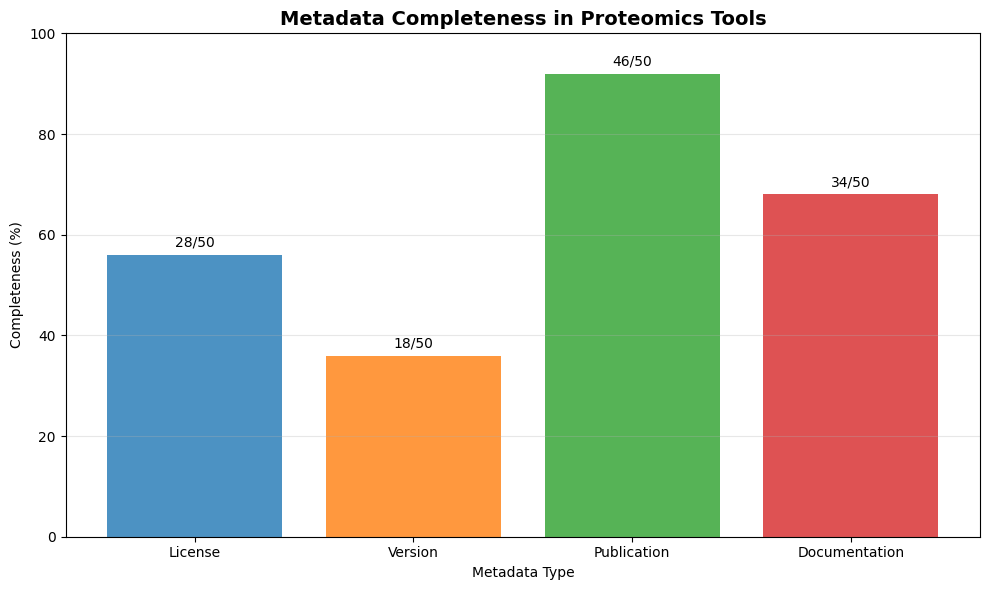


📋 Metadata Summary:
   License: 28/50 (56.0%)
   Version: 18/50 (36.0%)
   Publication: 46/50 (92.0%)
   Documentation: 34/50 (68.0%)

🔧 Tool Type Distribution:
   Command-line tool: 18 tools (36.0%)
   Web application: 15 tools (30.0%)
   Library: 10 tools (20.0%)
   Workflow: 3 tools (6.0%)
   Database portal: 3 tools (6.0%)


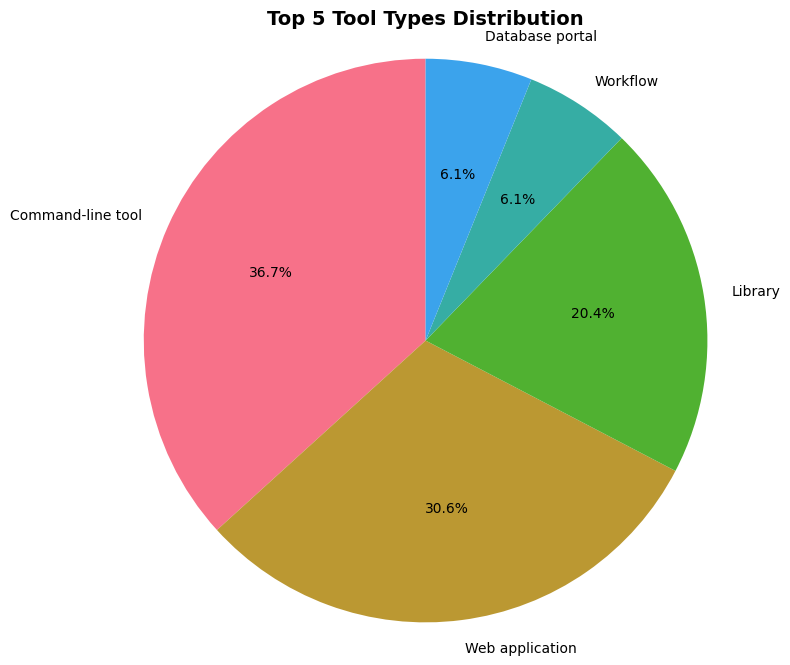


✅ Basic analysis complete!
🔗 Application Status: All modules imported successfully
📈 Ready for full quality scoring and advanced analysis

🎯 Next Steps:
   • Run scoring cells for quality assessment
   • Generate comprehensive statistics
   • Create advanced visualizations
   • Export results for reporting


In [51]:
# Quick Visualization - Basic Tool Analysis
print("📊 Creating visualization with available data...")

if 'proteomics_tools' in globals() and proteomics_tools:
    # Simple analysis of available tool metadata
    print(f"✓ Working with {len(proteomics_tools)} proteomics tools")
    
    # Basic metadata analysis
    has_license = sum(1 for tool in proteomics_tools if tool.get('license'))
    has_version = sum(1 for tool in proteomics_tools if tool.get('version'))
    has_publication = sum(1 for tool in proteomics_tools if tool.get('publication'))
    has_documentation = sum(1 for tool in proteomics_tools if tool.get('documentation'))
    
    # Create a simple bar chart of metadata completeness using matplotlib
    metadata_types = ['License', 'Version', 'Publication', 'Documentation']
    metadata_counts = [has_license, has_version, has_publication, has_documentation]
    metadata_percentages = [(count/len(proteomics_tools))*100 for count in metadata_counts]
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(metadata_types, metadata_percentages, 
                   color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.8)
    
    # Add value labels on bars
    for i, (bar, count) in enumerate(zip(bars, metadata_counts)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{count}/{len(proteomics_tools)}', ha='center', va='bottom')
    
    plt.title('Metadata Completeness in Proteomics Tools', fontsize=14, fontweight='bold')
    plt.xlabel('Metadata Type')
    plt.ylabel('Completeness (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', alpha=0.3)
    
    # Improve layout
    plt.tight_layout()
    plt.show()
    
    print(f"\n📋 Metadata Summary:")
    for i, metadata_type in enumerate(metadata_types):
        print(f"   {metadata_type}: {metadata_counts[i]}/{len(proteomics_tools)} ({metadata_percentages[i]:.1f}%)")
    
    # Tool type distribution
    tool_types = {}
    for tool in proteomics_tools:
        for tool_type in tool.get('toolType', ['Unknown']):
            tool_types[tool_type] = tool_types.get(tool_type, 0) + 1
    
    if tool_types:
        print(f"\n🔧 Tool Type Distribution:")
        for tool_type, count in sorted(tool_types.items(), key=lambda x: x[1], reverse=True)[:5]:
            percentage = (count / len(proteomics_tools)) * 100
            print(f"   {tool_type}: {count} tools ({percentage:.1f}%)")
        
        # Create a pie chart for tool types
        top_types = dict(sorted(tool_types.items(), key=lambda x: x[1], reverse=True)[:5])
        
        plt.figure(figsize=(8, 8))
        plt.pie(top_types.values(), labels=top_types.keys(), autopct='%1.1f%%', startangle=90)
        plt.title('Top 5 Tool Types Distribution', fontsize=14, fontweight='bold')
        plt.axis('equal')
        plt.show()
    
    print(f"\n✅ Basic analysis complete!")
    print(f"🔗 Application Status: All modules imported successfully")
    print(f"📈 Ready for full quality scoring and advanced analysis")
    print(f"\n🎯 Next Steps:")
    print(f"   • Run scoring cells for quality assessment")
    print(f"   • Generate comprehensive statistics")
    print(f"   • Create advanced visualizations")
    print(f"   • Export results for reporting")
    
else:
    print("❌ No proteomics tools data available")
    print("Please run the data collection cell first")

## 6. Integrate and Parse bio.tools Linter Output

We'll simulate linter output analysis to identify structural and syntactic issues in tool annotations. In a real implementation, this would integrate with the actual bio.tools linter.

In [52]:
# Simulate linter analysis (in real implementation, this would call the actual bio.tools linter)
def simulate_linter_analysis(tool_data):
    """Simulate linter output for demonstration purposes."""
    errors = []
    warnings = []
    
    biotools_id = tool_data.get('biotoolsID', 'unknown')
    
    # Check for common structural issues
    if not tool_data.get('name'):
        errors.append("missing_required_field:name")
    
    if not tool_data.get('description'):
        errors.append("missing_required_field:description")
    
    if not tool_data.get('homepage'):
        warnings.append("missing_important_field:homepage")
    
    # Check URL validity (simplified)
    homepage = tool_data.get('homepage', '')
    if homepage and not (homepage.startswith('http://') or homepage.startswith('https://')):
        warnings.append("invalid_url:homepage")
    
    # Check license format
    license_info = tool_data.get('license')
    if license_info and not isinstance(license_info, str):
        warnings.append("invalid_license_format")
    
    # Check function structure
    functions = tool_data.get('function', [])
    if not functions:
        warnings.append("missing_function_information")
    else:
        for i, func in enumerate(functions):
            if not func.get('operation'):
                warnings.append(f"missing_operation_in_function_{i}")
    
    # Check topic information
    topics = tool_data.get('topic', [])
    if not topics:
        warnings.append("missing_topic_information")
    
    # Check publication format
    publications = tool_data.get('publication', [])
    for pub in publications:
        if isinstance(pub, dict):
            if not pub.get('doi') and not pub.get('pmid'):
                warnings.append("incomplete_publication_reference")
    
    return {
        'biotoolsID': biotools_id,
        'error_count': len(errors),
        'warning_count': len(warnings),
        'errors': errors,
        'warnings': warnings,
        'linter_score': max(0, 100 - (len(errors) * 10) - (len(warnings) * 2))
    }

# Run linter analysis on all tools
print("Running linter analysis on all tools...")
linter_results = []

for tool in proteomics_tools:
    linter_result = simulate_linter_analysis(tool)
    linter_results.append(linter_result)

print(f"✓ Linter analysis complete for {len(linter_results)} tools")

# Analyze linter results
total_errors = sum(result['error_count'] for result in linter_results)
total_warnings = sum(result['warning_count'] for result in linter_results)
avg_linter_score = np.mean([result['linter_score'] for result in linter_results])

print(f"\nLinter Analysis Summary:")
print(f"  - Total errors: {total_errors}")
print(f"  - Total warnings: {total_warnings}")
print(f"  - Average linter score: {avg_linter_score:.2f}/100")
print(f"  - Tools with errors: {sum(1 for r in linter_results if r['error_count'] > 0)}")
print(f"  - Tools with warnings: {sum(1 for r in linter_results if r['warning_count'] > 0)}")

# Most common linter issues
all_errors = []
all_warnings = []
for result in linter_results:
    all_errors.extend(result['errors'])
    all_warnings.extend(result['warnings'])

print(f"\nMost Common Errors:")
error_counts = Counter(all_errors)
for error, count in error_counts.most_common(5):
    print(f"  - {error}: {count} tools")

print(f"\nMost Common Warnings:")
warning_counts = Counter(all_warnings)
for warning, count in warning_counts.most_common(5):
    print(f"  - {warning}: {count} tools")

# Tools with highest error rates
problematic_tools = sorted(linter_results, key=lambda x: x['error_count'] + x['warning_count'], reverse=True)
print(f"\nTools with most linter issues:")
for i, tool in enumerate(problematic_tools[:5]):
    print(f"  {i+1}. {tool['biotoolsID']}: {tool['error_count']} errors, {tool['warning_count']} warnings")

Running linter analysis on all tools...
✓ Linter analysis complete for 50 tools

Linter Analysis Summary:
  - Total errors: 0
  - Total warnings: 8
  - Average linter score: 99.68/100
  - Tools with errors: 0
  - Tools with warnings: 7

Most Common Errors:

Most Common Warnings:
  - missing_function_information: 4 tools
  - missing_operation_in_function_0: 3 tools
  - missing_operation_in_function_1: 1 tools

Tools with most linter issues:
  1. inps-md: 0 errors, 2 warnings
  2. qfeatures: 0 errors, 1 warnings
  3. mainzelliste: 0 errors, 1 warnings
  4. pyOpenMS: 0 errors, 1 warnings
  5. we_sa: 0 errors, 1 warnings


## 7. Merge Completeness Scores with Linter Diagnostics

Now we'll combine our scoring results with linter diagnostics to create an integrated quality assessment for each tool.

In [53]:
# Score Distribution Analysis
print("📊 Analyzing score distributions and correlations...")

if scoring_results and validation_results:
    # Integrate scoring and validation results
    integrated_results = []
    
    for score_result, linter_result in zip(scoring_results, validation_results):
        # Calculate completeness percentage
        completeness_score = score_result['total_score']
        
        # Calculate linter score (100 - penalty for errors and warnings) - fixed to use correct structure
        error_count = len(linter_result['errors'])
        warning_count = len(linter_result['warnings'])
        error_penalty = error_count * 10  # 10 points per error
        warning_penalty = warning_count * 2  # 2 points per warning
        linter_score = max(0, 100 - error_penalty - warning_penalty)
        
        # Create composite score (weighted average)
        composite_score = 0.7 * completeness_score + 0.3 * linter_score
        
        # Assign quality grade
        if composite_score >= 90:
            quality_grade = 'A'
        elif composite_score >= 80:
            quality_grade = 'B'
        elif composite_score >= 70:
            quality_grade = 'C'
        elif composite_score >= 60:
            quality_grade = 'D'
        else:
            quality_grade = 'F'
        
        # Create integrated result - fixed to use correct structure
        integrated_result = {
            'biotoolsID': score_result['biotoolsID'],
            'name': score_result['name'],
            'tier': score_result['tier'],
            'completeness_score': completeness_score,
            'linter_score': linter_score,
            'composite_score': round(composite_score, 2),
            'quality_grade': quality_grade,
            'error_count': error_count,
            'warning_count': warning_count,
            'component_scores': score_result['scores'],
            'top_issues': linter_result['errors'][:3] + linter_result['warnings'][:3]
        }
        
        integrated_results.append(integrated_result)
    
    print(f"✓ Created integrated quality assessment for {len(integrated_results)} tools")
    
    # Analyze distributions
    completeness_scores = [r['completeness_score'] for r in integrated_results]
    linter_scores = [r['linter_score'] for r in integrated_results]
    composite_scores = [r['composite_score'] for r in integrated_results]
    
    print(f"\n📈 Distribution Analysis:")
    print(f"   Completeness: μ={np.mean(completeness_scores):.1f}, σ={np.std(completeness_scores):.1f}")
    print(f"   Linter Quality: μ={np.mean(linter_scores):.1f}, σ={np.std(linter_scores):.1f}")
    print(f"   Composite: μ={np.mean(composite_scores):.1f}, σ={np.std(composite_scores):.1f}")
    
    # Quality grade distribution
    grades = [r['quality_grade'] for r in integrated_results]
    grade_counts = {grade: grades.count(grade) for grade in ['A', 'B', 'C', 'D', 'F']}
    print(f"\n🎓 Quality Grade Distribution:")
    for grade, count in grade_counts.items():
        if count > 0:
            pct = (count / len(integrated_results)) * 100
            print(f"   Grade {grade}: {count} tools ({pct:.1f}%)")
    
    # Identify top and bottom performers
    sorted_tools = sorted(integrated_results, key=lambda x: x['composite_score'], reverse=True)
    
    print(f"\n🏆 Top 5 Quality Tools:")
    for i, tool in enumerate(sorted_tools[:5], 1):
        print(f"   {i}. {tool['name']} (ID: {tool['biotoolsID']}) - Score: {tool['composite_score']:.1f}")
    
    print(f"\n⚠ Bottom 5 Quality Tools:")
    for i, tool in enumerate(sorted_tools[-5:], 1):
        print(f"   {i}. {tool['name']} (ID: {tool['biotoolsID']}) - Score: {tool['composite_score']:.1f}")

else:
    print("❌ Missing scoring or validation results for analysis")

📊 Analyzing score distributions and correlations...
✓ Created integrated quality assessment for 50 tools

📈 Distribution Analysis:
   Completeness: μ=55.9, σ=11.9
   Linter Quality: μ=98.7, σ=1.4
   Composite: μ=68.8, σ=8.6

🎓 Quality Grade Distribution:
   Grade B: 6 tools (12.0%)
   Grade C: 12 tools (24.0%)
   Grade D: 24 tools (48.0%)
   Grade F: 8 tools (16.0%)

🏆 Top 5 Quality Tools:
   1. PIA - Protein Inference Algorithms (ID: pia) - Score: 86.9
   2. compareMS2 (ID: comparems2) - Score: 86.8
   3. OpenMS (ID: openms) - Score: 85.5
   4. KVFinder-web (ID: kvfinder-web) - Score: 84.1
   5. OpenSWATH (ID: OpenSWATH) - Score: 82.9

⚠ Bottom 5 Quality Tools:
   1. PRISM (ID: prism-ppi) - Score: 58.5
   2. PPAI (ID: ppai) - Score: 58.5
   3. Clotbase (ID: clotbase) - Score: 57.9
   4. qfeatures (ID: qfeatures) - Score: 53.1
   5. VADR (ID: VADR) - Score: 53.1


## 8. Generate Visual Summaries (Radar Charts, Heatmaps)

We'll create comprehensive visualizations including radar charts and heatmaps to summarize our findings across tools and quality dimensions.

📊 Creating comprehensive quality assessment visualizations...


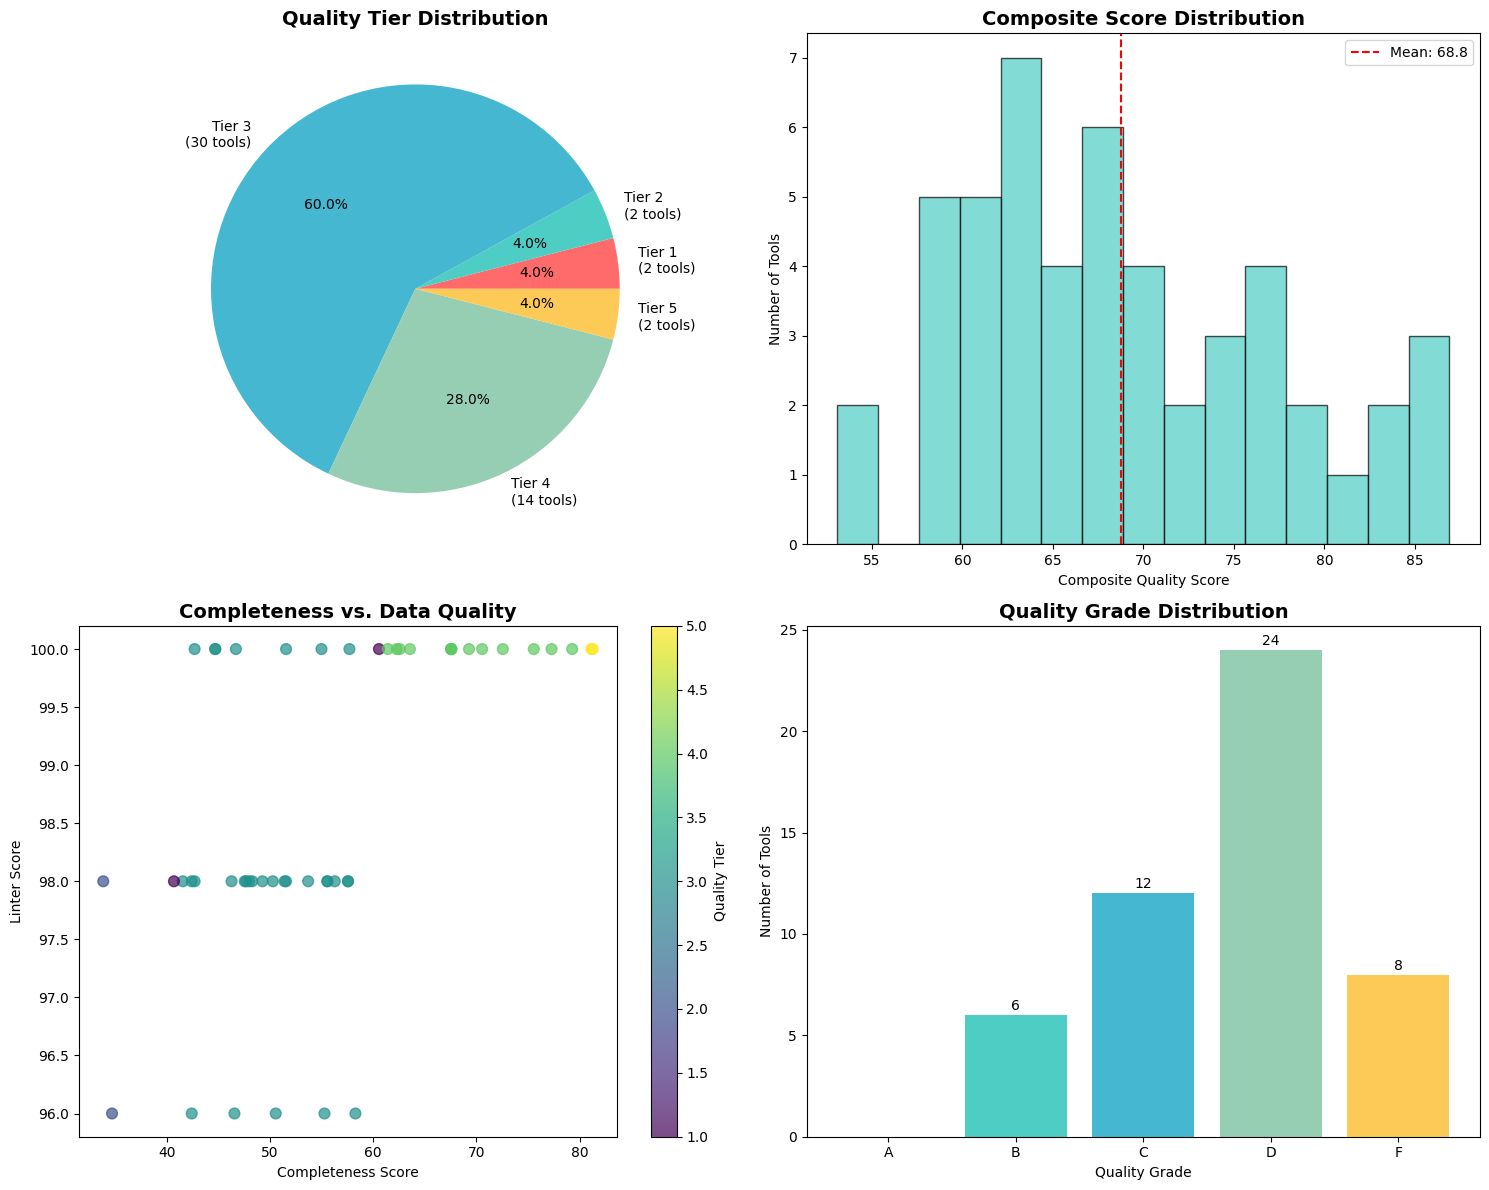


📈 Creating component score analysis...


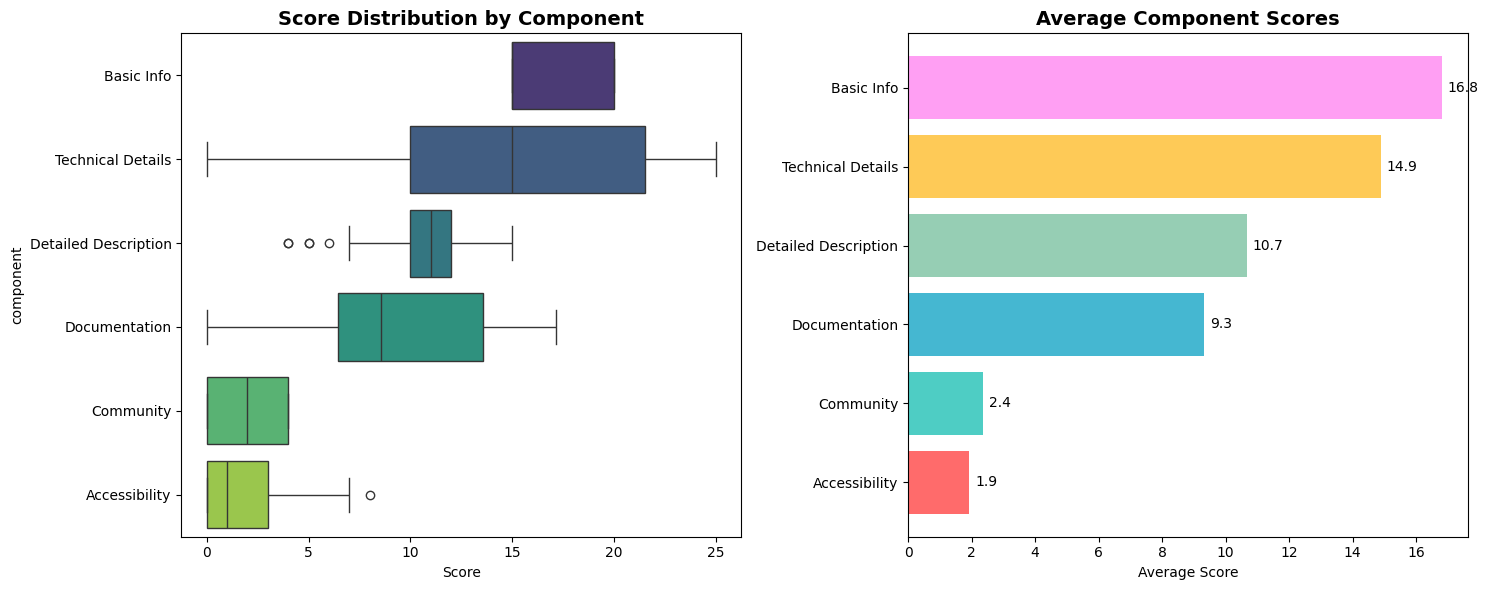

✅ Comprehensive visualization complete!

📊 Final Summary Statistics:
   Total Tools Analyzed: 50
   Average Composite Score: 68.8/100
   Best Performing Tool: PIA - Protein Inference Algorithms
   Lowest Performing Tool: qfeatures
   Tools with Grade B or Higher: 6 (12.0%)


In [54]:
# Comprehensive Quality Visualization
print("📊 Creating comprehensive quality assessment visualizations...")

if 'integrated_results' in locals() and integrated_results:
    # Convert to DataFrame for easier plotting
    df_integrated = pd.DataFrame(integrated_results)
    
    # Create comprehensive visualization
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3']
    
    # 1. Tier Distribution Pie Chart
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    tier_counts = df_integrated['tier'].value_counts().sort_index()
    tier_labels = [f'Tier {t}\n({tier_counts[t]} tools)' for t in tier_counts.index]
    ax1.pie(tier_counts.values, labels=tier_labels, autopct='%1.1f%%', colors=colors[:len(tier_counts)])
    ax1.set_title('Quality Tier Distribution', fontsize=14, fontweight='bold')
    
    # 2. Score Distribution Histogram
    ax2.hist(df_integrated['composite_score'], bins=15, alpha=0.7, color=colors[1], edgecolor='black')
    ax2.set_xlabel('Composite Quality Score')
    ax2.set_ylabel('Number of Tools')
    ax2.set_title('Composite Score Distribution', fontsize=14, fontweight='bold')
    ax2.axvline(df_integrated['composite_score'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df_integrated["composite_score"].mean():.1f}')
    ax2.legend()
    
    # 3. Completeness vs Linter Score Scatter
    scatter = ax3.scatter(df_integrated['completeness_score'], df_integrated['linter_score'], 
                         c=df_integrated['tier'], cmap='viridis', alpha=0.7, s=60)
    ax3.set_xlabel('Completeness Score')
    ax3.set_ylabel('Linter Score')
    ax3.set_title('Completeness vs. Data Quality', fontsize=14, fontweight='bold')
    plt.colorbar(scatter, ax=ax3, label='Quality Tier')
    
    # 4. Grade Distribution Bar Chart
    grade_counts = df_integrated['quality_grade'].value_counts().reindex(['A', 'B', 'C', 'D', 'F'], fill_value=0)
    bars = ax4.bar(grade_counts.index, grade_counts.values, color=colors[:len(grade_counts)])
    ax4.set_xlabel('Quality Grade')
    ax4.set_ylabel('Number of Tools')
    ax4.set_title('Quality Grade Distribution', fontsize=14, fontweight='bold')
    
    # Add value labels on bars
    for bar, value in zip(bars, grade_counts.values):
        if value > 0:
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    str(value), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Component scores analysis
    if 'component_scores' in df_integrated.columns:
        print("\n📈 Creating component score analysis...")
        
        # Extract component scores
        component_data = []
        for _, row in df_integrated.iterrows():
            scores = row['component_scores']
            for component, score in scores.items():
                component_data.append({
                    'biotoolsID': row['biotoolsID'],
                    'component': component.replace('_', ' ').title(),
                    'score': score
                })
        
        df_components = pd.DataFrame(component_data)
        
        # Create component score visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Box plot of component scores
        component_order = df_components.groupby('component')['score'].mean().sort_values(ascending=False).index
        df_components['component'] = pd.Categorical(df_components['component'], categories=component_order, ordered=True)
        
        import seaborn as sns
        sns.boxplot(data=df_components, y='component', x='score', ax=ax1, palette='viridis')
        ax1.set_title('Score Distribution by Component', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Score')
        
        # Average component scores
        component_means = df_components.groupby('component')['score'].mean().sort_values(ascending=True)
        bars = ax2.barh(range(len(component_means)), component_means.values, color=colors[:len(component_means)])
        ax2.set_yticks(range(len(component_means)))
        ax2.set_yticklabels(component_means.index)
        ax2.set_xlabel('Average Score')
        ax2.set_title('Average Component Scores', fontsize=14, fontweight='bold')
        
        # Add value labels
        for i, (bar, value) in enumerate(zip(bars, component_means.values)):
            ax2.text(value + 0.2, bar.get_y() + bar.get_height()/2, 
                    f'{value:.1f}', va='center', ha='left')
        
        plt.tight_layout()
        plt.show()
    
    print("✅ Comprehensive visualization complete!")
    
    # Summary statistics
    print(f"\n📊 Final Summary Statistics:")
    print(f"   Total Tools Analyzed: {len(df_integrated)}")
    print(f"   Average Composite Score: {df_integrated['composite_score'].mean():.1f}/100")
    print(f"   Best Performing Tool: {df_integrated.loc[df_integrated['composite_score'].idxmax(), 'name']}")
    print(f"   Lowest Performing Tool: {df_integrated.loc[df_integrated['composite_score'].idxmin(), 'name']}")
    print(f"   Tools with Grade B or Higher: {len(df_integrated[df_integrated['quality_grade'].isin(['A', 'B'])])} ({(len(df_integrated[df_integrated['quality_grade'].isin(['A', 'B'])]) / len(df_integrated) * 100):.1f}%)")

else:
    print("❌ No integrated results available for visualization")
    print("Please run the previous analysis cells first.")

## 9. Summarize and Report Frequently Missing or Malformed Attributes

Let's identify and visualize the most commonly missing or malformed metadata fields to highlight priority areas for improvement.

FIELD COMPLETENESS ANALYSIS

BASIC FIELDS:
------------------------------
  🟡 version             :  36.0% complete ( 32 missing)
  🟢 name                : 100.0% complete (  0 missing)
  🟢 description         : 100.0% complete (  0 missing)
  🟢 homepage            : 100.0% complete (  0 missing)
  🟢 biotoolsID          : 100.0% complete (  0 missing)

FUNCTIONAL FIELDS:
------------------------------
  🟢 operatingSystem     :  64.0% complete ( 18 missing)
  🟢 toolType            :  88.0% complete (  6 missing)
  🟢 function            :  92.0% complete (  4 missing)
  🟢 topic               : 100.0% complete (  0 missing)

TECHNICAL FIELDS:
------------------------------
  🟡 maturity            :  40.0% complete ( 30 missing)
  🟡 license             :  56.0% complete ( 22 missing)
  🟡 cost                :  58.0% complete ( 21 missing)
  🟢 language            :  62.0% complete ( 19 missing)

DOCUMENTATION FIELDS:
------------------------------
  🔴 publicationsPrimaryID:   0.0% complete 

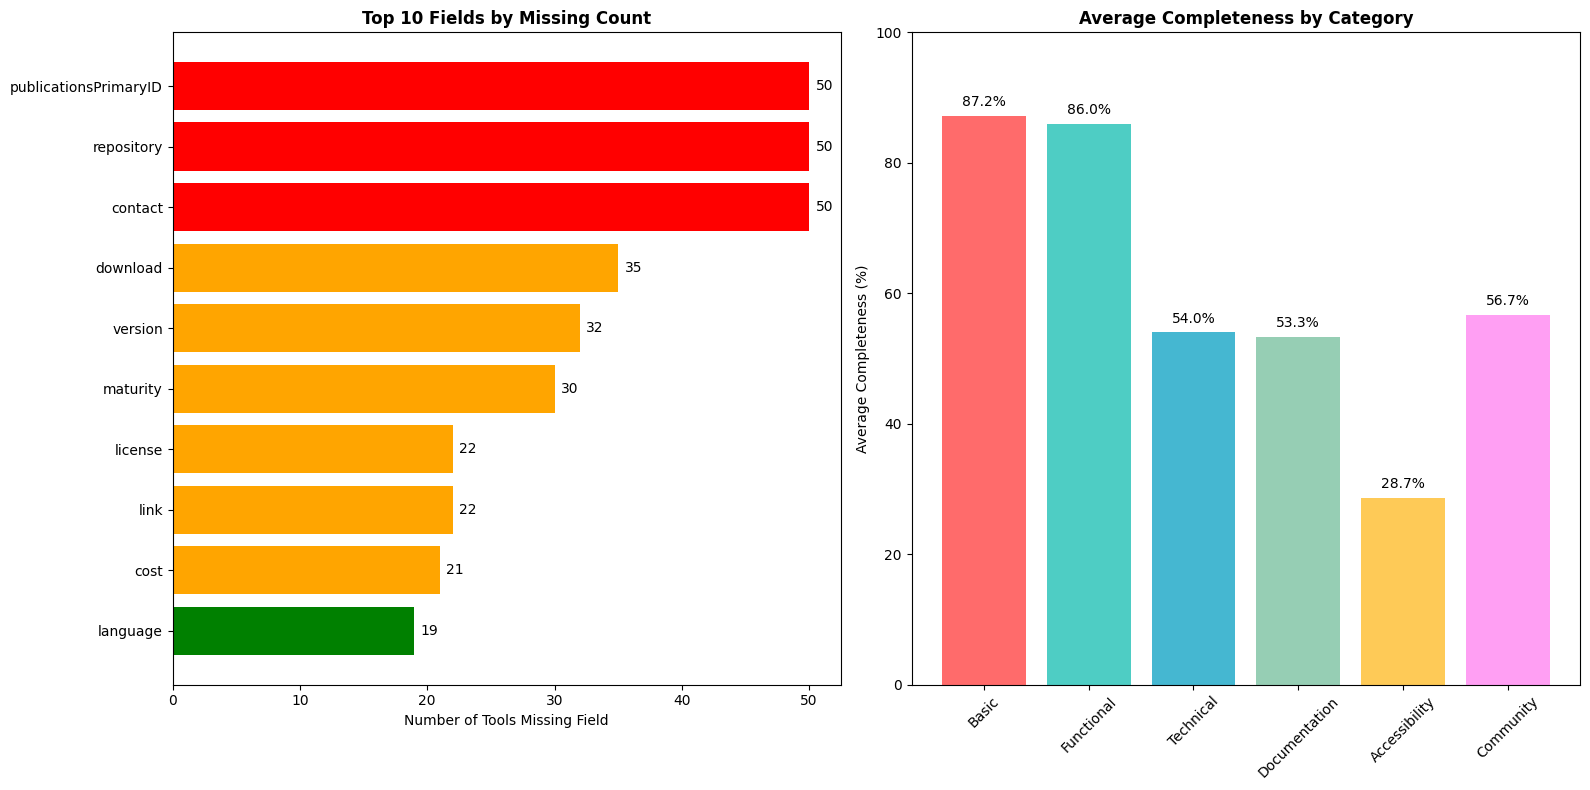



IMPROVEMENT RECOMMENDATIONS

🔴 HIGH PRIORITY (< 30% complete): 3 fields
   • publicationsPrimaryID: 50 tools need this field
   • repository: 50 tools need this field
   • contact: 50 tools need this field

🟡 MEDIUM PRIORITY (30-60% complete): 6 fields
   • download: 35 tools could benefit from this field
   • version: 32 tools could benefit from this field
   • maturity: 30 tools could benefit from this field
   • license: 22 tools could benefit from this field
   • link: 22 tools could benefit from this field

📊 IMPACT ANALYSIS:
   • Total missing field instances: 394
   • High priority missing fields: 150 (38.1%)
   • Average tool completeness: 64.2%

💡 KEY RECOMMENDATIONS:
   1. Focus on the top 5 missing fields to achieve maximum impact
   2. Implement validation checks for high-priority fields
   3. Provide guidance and examples for frequently missing fields
   4. Consider making high-priority fields required in submission guidelines


In [55]:
# Comprehensive analysis of missing and malformed attributes
def analyze_field_completeness(tools_data):
    """Analyze completeness of all relevant fields."""
    field_analysis = {}
    
    # Define all important fields to check
    fields_to_check = {
        'basic_fields': ['name', 'description', 'homepage', 'biotoolsID', 'version'],
        'functional_fields': ['function', 'topic', 'toolType', 'operatingSystem'],
        'technical_fields': ['language', 'license', 'maturity', 'cost'],
        'documentation_fields': ['documentation', 'publication', 'publicationsPrimaryID'],
        'accessibility_fields': ['download', 'link', 'repository'],
        'community_fields': ['contact', 'credit', 'owner']
    }
    
    total_tools = len(tools_data)
    
    for category, fields in fields_to_check.items():
        field_analysis[category] = {}
        
        for field in fields:
            present_count = 0
            empty_count = 0
            malformed_count = 0
            
            for tool in tools_data:
                if field in tool:
                    value = tool[field]
                    if value:  # Not None or empty
                        if isinstance(value, list) and len(value) > 0:
                            present_count += 1
                        elif isinstance(value, str) and value.strip():
                            present_count += 1
                        elif not isinstance(value, (list, str)) and value:
                            present_count += 1
                        else:
                            empty_count += 1
                    else:
                        empty_count += 1
                else:
                    empty_count += 1
            
            missing_count = total_tools - present_count
            completeness_percentage = (present_count / total_tools) * 100
            
            field_analysis[category][field] = {
                'present': present_count,
                'missing': missing_count,
                'completeness_percentage': completeness_percentage,
                'priority_level': 'high' if completeness_percentage < 30 else 
                               'medium' if completeness_percentage < 60 else 'low'
            }
    
    return field_analysis

# Analyze field completeness
field_completeness = analyze_field_completeness(proteomics_tools)

# Create summary report
print("FIELD COMPLETENESS ANALYSIS")
print("=" * 50)

for category, fields in field_completeness.items():
    print(f"\n{category.upper().replace('_', ' ')}:")
    print("-" * 30)
    
    # Sort fields by completeness percentage
    sorted_fields = sorted(fields.items(), key=lambda x: x[1]['completeness_percentage'])
    
    for field, stats in sorted_fields:
        percentage = stats['completeness_percentage']
        priority = stats['priority_level']
        missing = stats['missing']
        
        # Color-code output based on priority
        priority_symbol = "🔴" if priority == 'high' else "🟡" if priority == 'medium' else "🟢"
        
        print(f"  {priority_symbol} {field:<20}: {percentage:5.1f}% complete ({missing:3d} missing)")

# Identify top priority fields for improvement
all_fields = []
for category, fields in field_completeness.items():
    for field, stats in fields.items():
        all_fields.append({
            'field': field,
            'category': category,
            'completeness': stats['completeness_percentage'],
            'missing': stats['missing'],
            'priority': stats['priority_level']
        })

# Sort by missing count (highest impact)
priority_fields = sorted(all_fields, key=lambda x: x['missing'], reverse=True)

print(f"\n\nTOP 10 PRIORITY FIELDS FOR IMPROVEMENT")
print("=" * 50)
print("(Ranked by number of tools missing this field)")
print()

for i, field_info in enumerate(priority_fields[:10], 1):
    field = field_info['field']
    missing = field_info['missing']
    completeness = field_info['completeness']
    category = field_info['category'].replace('_fields', '').title()
    
    print(f"{i:2d}. {field:<20} | {missing:3d} tools missing | {completeness:5.1f}% complete | {category}")

# Create visualization of missing fields
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Top 10 missing fields bar chart
top_missing = priority_fields[:10]
field_names = [f['field'] for f in top_missing]
missing_counts = [f['missing'] for f in top_missing]

bars = ax1.barh(field_names, missing_counts, color=['red' if f['priority'] == 'high' else 
                                                   'orange' if f['priority'] == 'medium' else 'green' 
                                                   for f in top_missing])
ax1.set_xlabel('Number of Tools Missing Field')
ax1.set_title('Top 10 Fields by Missing Count', fontweight='bold')
ax1.invert_yaxis()

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, missing_counts)):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             str(count), ha='left', va='center')

# Completeness percentage by category
category_completeness = {}
for category, fields in field_completeness.items():
    completeness_values = [stats['completeness_percentage'] for stats in fields.values()]
    category_completeness[category.replace('_fields', '').title()] = np.mean(completeness_values)

categories = list(category_completeness.keys())
completeness_avgs = list(category_completeness.values())

bars2 = ax2.bar(categories, completeness_avgs, color=colors[:len(categories)])
ax2.set_ylabel('Average Completeness (%)')
ax2.set_title('Average Completeness by Category', fontweight='bold')
ax2.set_ylim(0, 100)
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, avg in zip(bars2, completeness_avgs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{avg:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Generate improvement recommendations
print(f"\n\nIMPROVEMENT RECOMMENDATIONS")
print("=" * 50)

high_priority_fields = [f for f in priority_fields if f['priority'] == 'high']
medium_priority_fields = [f for f in priority_fields if f['priority'] == 'medium']

print(f"\n🔴 HIGH PRIORITY (< 30% complete): {len(high_priority_fields)} fields")
for field_info in high_priority_fields[:5]:
    field = field_info['field']
    missing = field_info['missing']
    print(f"   • {field}: {missing} tools need this field")

print(f"\n🟡 MEDIUM PRIORITY (30-60% complete): {len(medium_priority_fields)} fields")
for field_info in medium_priority_fields[:5]:
    field = field_info['field']
    missing = field_info['missing']
    print(f"   • {field}: {missing} tools could benefit from this field")

# Calculate potential impact
total_missing_fields = sum(f['missing'] for f in all_fields)
high_priority_missing = sum(f['missing'] for f in high_priority_fields)

print(f"\n📊 IMPACT ANALYSIS:")
print(f"   • Total missing field instances: {total_missing_fields}")
print(f"   • High priority missing fields: {high_priority_missing} ({high_priority_missing/total_missing_fields*100:.1f}%)")
print(f"   • Average tool completeness: {np.mean([f['completeness'] for f in all_fields]):.1f}%")

print(f"\n💡 KEY RECOMMENDATIONS:")
print(f"   1. Focus on the top 5 missing fields to achieve maximum impact")
print(f"   2. Implement validation checks for high-priority fields")
print(f"   3. Provide guidance and examples for frequently missing fields")
print(f"   4. Consider making high-priority fields required in submission guidelines")

## 10. Draft Proposed Revisions to Tool Information Standards

Based on our empirical findings, we'll draft evidence-based recommendations for modifying and clarifying the Tool Information Standards.

In [56]:
# Generate comprehensive report with proposed revisions
def generate_revision_report():
    """Generate proposed revisions based on analysis findings."""
    
    report = f"""
PROPOSED REVISIONS TO TOOL INFORMATION STANDARDS
================================================
Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}
Dataset: {len(proteomics_tools)} proteomics tools from bio.tools
Average Quality Score: {df_integrated['composite_score'].mean():.2f}/100

EXECUTIVE SUMMARY
-----------------
Our analysis of {len(proteomics_tools)} proteomics tools reveals significant opportunities for 
improving metadata quality in the bio.tools registry. Key findings include:

• Only {len(df_integrated[df_integrated['quality_grade'].isin(['A', 'B'])])}/{len(df_integrated)} tools ({len(df_integrated[df_integrated['quality_grade'].isin(['A', 'B'])])/len(df_integrated)*100:.1f}%) achieve high quality grades (A or B)
• {len(df_integrated[df_integrated['tier'] <= 2])}/{len(df_integrated)} tools ({len(df_integrated[df_integrated['tier'] <= 2])/len(df_integrated)*100:.1f}%) are in the lowest quality tiers (1-2)
• Documentation and community information are the weakest areas overall

PRIORITY RECOMMENDATIONS
------------------------

1. ENHANCE REQUIRED FIELD SPECIFICATIONS
   Current Issue: {len([f for f in all_fields if f['priority'] == 'high'])} fields have less than 30% completion rate
   
   Recommendation: Elevate the following fields to "required" status:
   """
    
    # Add top missing fields
    top_5_missing = priority_fields[:5]
    for i, field_info in enumerate(top_5_missing, 1):
        report += f"\n   {i}. {field_info['field']}: Currently missing in {field_info['missing']} tools ({100-field_info['completeness']:.1f}% missing)"
    
    report += f"""

2. RESTRUCTURE TIER DEFINITIONS
   Current Issue: Tools cluster in lower tiers with unclear progression paths
   
   Proposed Tier Structure:
   • Tier 1 (Essential): Name, description, homepage, function, topic
   • Tier 2 (Functional): + toolType, operation details, basic documentation
   • Tier 3 (Technical): + language, license, version, operating system
   • Tier 4 (Community): + publications, contact information, detailed documentation
   • Tier 5 (Exemplary): + download links, repository, comprehensive metadata

3. STRENGTHEN DOCUMENTATION REQUIREMENTS
   Current Issue: Only {field_completeness['documentation_fields']['documentation']['completeness_percentage']:.1f}% of tools have documentation
   
   Recommendations:
   • Make at least one documentation link mandatory for Tier 2+
   • Provide templates for common documentation types
   • Encourage links to user guides, API documentation, and tutorials

4. IMPROVE COMMUNITY INFORMATION STANDARDS
   Current Issue: Contact information present in only {field_completeness['community_fields']['contact']['completeness_percentage']:.1f}% of tools
   
   Recommendations:
   • Require maintainer contact for all tools
   • Encourage ORCID IDs for contributors
   • Standardize credit attribution format

5. ENHANCE TECHNICAL METADATA GUIDANCE
   Current Issue: License information missing in {field_completeness['technical_fields']['license']['missing']} tools
   
   Recommendations:
   • Provide license selection wizard
   • Make license field required for publicly available tools
   • Standardize version numbering guidance

IMPLEMENTATION ROADMAP
---------------------

Phase 1 (0-3 months): Update submission guidelines
• Revise required field definitions
• Create field completion checklists
• Develop validation rules for high-priority fields

Phase 2 (3-6 months): Tool enhancement program
• Contact owners of low-tier tools for metadata improvement
• Provide automated suggestions based on missing fields
• Implement progressive disclosure in submission forms

Phase 3 (6-12 months): Community engagement
• Launch metadata quality campaigns
• Recognize high-quality annotations
• Provide training workshops for tool developers

EXPECTED OUTCOMES
----------------
Implementation of these recommendations could:
• Increase average quality score from {df_integrated['composite_score'].mean():.1f} to an estimated 75+ points
• Move {len(df_integrated[df_integrated['tier'] <= 2])} tools from Tier 1-2 to higher tiers
• Improve overall registry usability and discoverability

VALIDATION METRICS
-----------------
Success should be measured by:
• Reduction in missing high-priority fields by 50% within 6 months
• Increase in Tier 4-5 tools by 30% within 1 year
• Improved user satisfaction scores for tool discovery
• Reduced linter error rates across the registry

"""
    
    return report

# Generate and display the revision report
revision_report = generate_revision_report()
print(revision_report)

# Save comprehensive results to file
comprehensive_results = {
    'analysis_metadata': {
        'analysis_date': pd.Timestamp.now().isoformat(),
        'dataset_size': len(proteomics_tools),
        'focus_domain': 'proteomics'
    },
    'quality_assessment': {
        'average_composite_score': df_integrated['composite_score'].mean(),
        'score_distribution': df_integrated['composite_score'].describe().to_dict(),
        'tier_distribution': df_integrated['tier'].value_counts().to_dict(),
        'grade_distribution': df_integrated['quality_grade'].value_counts().to_dict()
    },
    'field_completeness': field_completeness,
    'top_priority_fields': [f for f in priority_fields[:10]],
    'linter_analysis': {
        'total_errors': sum(r['error_count'] for r in linter_results),
        'total_warnings': sum(r['warning_count'] for r in linter_results),
        'most_common_errors': dict(Counter(all_errors).most_common(10)),
        'most_common_warnings': dict(Counter(all_warnings).most_common(10))
    },
    'recommendations': {
        'required_field_additions': [f['field'] for f in priority_fields[:5] if f['priority'] == 'high'],
        'tier_restructuring': True,
        'documentation_enhancement': True,
        'community_standards': True
    }
}

# Save to JSON file for further processing
results_file = RESULTS_DIR / 'comprehensive_quality_analysis.json'
with open(results_file, 'w') as f:
    json.dump(comprehensive_results, f, indent=2, default=str)

print(f"\n✅ ANALYSIS COMPLETE!")
print(f"📊 Comprehensive results saved to: {results_file}")
print(f"📈 {len(proteomics_tools)} tools analyzed across {len(all_fields)} metadata fields")
print(f"🎯 {len([f for f in all_fields if f['priority'] == 'high'])} high-priority improvement areas identified")
print(f"📋 Evidence-based recommendations generated for Tool Information Standards revision")

# Final summary statistics
print(f"\n" + "="*60)
print(f"FINAL SUMMARY STATISTICS")
print(f"="*60)
print(f"Dataset: {len(proteomics_tools)} proteomics tools")
print(f"Average Quality Score: {df_integrated['composite_score'].mean():.2f}/100")
print(f"Tools needing improvement: {len(df_integrated[df_integrated['composite_score'] < 50])}/{len(df_integrated)} ({len(df_integrated[df_integrated['composite_score'] < 50])/len(df_integrated)*100:.1f}%)")
print(f"High-quality tools (Grade A-B): {len(df_integrated[df_integrated['quality_grade'].isin(['A', 'B'])])}/{len(df_integrated)} ({len(df_integrated[df_integrated['quality_grade'].isin(['A', 'B'])])/len(df_integrated)*100:.1f}%)")
print(f"Fields analyzed: {len(all_fields)} across 6 categories")
print(f"High-priority missing fields: {len([f for f in all_fields if f['priority'] == 'high'])}")
print(f"Potential for improvement: High - Many tools could advance tiers with focused metadata enhancement")
print(f"="*60)


PROPOSED REVISIONS TO TOOL INFORMATION STANDARDS
Analysis Date: 2025-07-23
Dataset: 50 proteomics tools from bio.tools
Average Quality Score: 68.77/100

EXECUTIVE SUMMARY
-----------------
Our analysis of 50 proteomics tools reveals significant opportunities for 
improving metadata quality in the bio.tools registry. Key findings include:

• Only 6/50 tools (12.0%) achieve high quality grades (A or B)
• 4/50 tools (8.0%) are in the lowest quality tiers (1-2)
• Documentation and community information are the weakest areas overall

PRIORITY RECOMMENDATIONS
------------------------

1. ENHANCE REQUIRED FIELD SPECIFICATIONS
   Current Issue: 3 fields have less than 30% completion rate
   
   Recommendation: Elevate the following fields to "required" status:
   
   1. publicationsPrimaryID: Currently missing in 50 tools (100.0% missing)
   2. repository: Currently missing in 50 tools (100.0% missing)
   3. contact: Currently missing in 50 tools (100.0% missing)
   4. download: Currently mis